In [1]:
!pip install -q datasets transformers evaluate accelerate scikit-learn pandas matplotlib seaborn

In [2]:
from datasets import load_dataset

dataset = load_dataset("derek-thomas/ScienceQA")

dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'question', 'choices', 'answer', 'hint', 'task', 'grade', 'subject', 'topic', 'category', 'skill', 'lecture', 'solution'],
        num_rows: 12726
    })
    validation: Dataset({
        features: ['image', 'question', 'choices', 'answer', 'hint', 'task', 'grade', 'subject', 'topic', 'category', 'skill', 'lecture', 'solution'],
        num_rows: 4241
    })
    test: Dataset({
        features: ['image', 'question', 'choices', 'answer', 'hint', 'task', 'grade', 'subject', 'topic', 'category', 'skill', 'lecture', 'solution'],
        num_rows: 4241
    })
})

In [3]:
print(dataset["train"].column_names)

['image', 'question', 'choices', 'answer', 'hint', 'task', 'grade', 'subject', 'topic', 'category', 'skill', 'lecture', 'solution']


In [4]:
dataset["train"][0]

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=750x429>,
 'question': 'Which of these states is farthest north?',
 'choices': ['West Virginia', 'Louisiana', 'Arizona', 'Oklahoma'],
 'answer': 0,
 'hint': '',
 'task': 'closed choice',
 'grade': 'grade2',
 'subject': 'social science',
 'topic': 'geography',
 'category': 'Geography',
 'skill': 'Read a map: cardinal directions',
 'lecture': 'Maps have four cardinal directions, or main directions. Those directions are north, south, east, and west.\nA compass rose is a set of arrows that point to the cardinal directions. A compass rose usually shows only the first letter of each cardinal direction.\nThe north arrow points to the North Pole. On most maps, north is at the top of the map.',
 'solution': 'To find the answer, look at the compass rose. Look at which way the north arrow is pointing. West Virginia is farthest north.'}

In [5]:
print("SUBJECTS:")
print(dataset["train"].unique("subject"))

print("\nTOPICS:")
print(dataset["train"].unique("topic"))

print("\nCATEGORIES:")
print(dataset["train"].unique("category"))

SUBJECTS:
['social science', 'natural science', 'language science']

TOPICS:
['geography', 'science-and-engineering-practices', 'verbs', 'chemistry', 'writing-strategies', 'biology', 'physics', 'units-and-measurement', 'figurative-language', 'economics', 'reference-skills', 'phonological-awareness', 'grammar', 'earth-science', 'punctuation', 'capitalization', 'us-history', 'reading-comprehension', 'world-history', 'civics', 'vocabulary', 'literacy-in-science', 'word-study', 'culture', 'pronouns', 'global-studies']

CATEGORIES:
['Geography', 'Designing experiments', 'Verb tense', 'Physical and chemical change', 'Pronouns', 'Genes to traits', 'Particle motion and energy', 'Ecological interactions', 'Solutions', 'Magnets', 'Units and measurement', 'Plants', 'Editing and revising', 'Traits and heredity', 'Materials', 'State capitals', 'Heredity', 'States of matter', 'Literary devices', 'Classification', 'Atoms and molecules', 'Basic economic principles', 'Animals', 'Heat and thermal energy

In [6]:
print("SUBJECT DISTRIBUTION")
print(dataset["train"].to_pandas()["subject"].value_counts())

print("\nTOPIC DISTRIBUTION")
print(dataset["train"].to_pandas()["topic"].value_counts())

print("\nCATEGORY DISTRIBUTION")
print(dataset["train"].to_pandas()["category"].value_counts())

SUBJECT DISTRIBUTION
subject
natural science     6873
language science    3243
social science      2610
Name: count, dtype: int64

TOPIC DISTRIBUTION
topic
biology                              2464
physics                              1923
geography                            1756
writing-strategies                    974
figurative-language                   739
chemistry                             735
earth-science                         682
science-and-engineering-practices     564
units-and-measurement                 484
reference-skills                      441
economics                             400
us-history                            322
punctuation                           322
grammar                               240
verbs                                 163
capitalization                        134
vocabulary                            101
civics                                 86
phonological-awareness                 52
reading-comprehension                  47
worl

In [7]:
topic_counts = dataset["train"].to_pandas()["topic"].value_counts()

print(topic_counts.to_string())

topic
biology                              2464
physics                              1923
geography                            1756
writing-strategies                    974
figurative-language                   739
chemistry                             735
earth-science                         682
science-and-engineering-practices     564
units-and-measurement                 484
reference-skills                      441
economics                             400
us-history                            322
punctuation                           322
grammar                               240
verbs                                 163
capitalization                        134
vocabulary                            101
civics                                 86
phonological-awareness                 52
reading-comprehension                  47
world-history                          39
word-study                             22
literacy-in-science                    21
pronouns                    

In [8]:
print("Number of unique topics:", dataset["train"].to_pandas()["topic"].nunique())

Number of unique topics: 26


In [9]:
df_train = dataset["train"].to_pandas()

science_topics = [
    "biology",
    "physics",
    "chemistry",
    "earth-science",
    "science-and-engineering-practices",
    "units-and-measurement"
]

science_df = df_train[df_train["topic"].isin(science_topics)]

print("Total science examples:", len(science_df))
print("\nScience topic distribution:")
print(science_df["topic"].value_counts())

Total science examples: 6852

Science topic distribution:
topic
biology                              2464
physics                              1923
chemistry                             735
earth-science                         682
science-and-engineering-practices     564
units-and-measurement                 484
Name: count, dtype: int64


In [10]:
for split in ["train", "validation", "test"]:
    df = dataset[split].to_pandas()

    science_domains = [
        "biology",
        "physics",
        "chemistry",
        "earth-science"
    ]

    filtered = df[df["topic"].isin(science_domains)]

    print("=" * 50)
    print(split.upper())
    print("Total examples:", len(filtered))
    print(filtered["topic"].value_counts())

TRAIN
Total examples: 5804
topic
biology          2464
physics          1923
chemistry         735
earth-science     682
Name: count, dtype: int64
VALIDATION
Total examples: 2004
topic
biology          834
physics          675
earth-science    249
chemistry        246
Name: count, dtype: int64
TEST
Total examples: 1851
topic
biology          800
physics          617
earth-science    221
chemistry        213
Name: count, dtype: int64


In [11]:
science_domains = [
    "biology",
    "physics",
    "chemistry",
    "earth-science"
]

train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

train_science = train_df[train_df["topic"].isin(science_domains)].copy()
val_science = val_df[val_df["topic"].isin(science_domains)].copy()
test_science = test_df[test_df["topic"].isin(science_domains)].copy()

print("Train:", len(train_science))
print("Validation:", len(val_science))
print("Test:", len(test_science))

Train: 5804
Validation: 2004
Test: 1851


In [12]:
train_clean = train_science[["question", "topic"]].copy()
val_clean = val_science[["question", "topic"]].copy()
test_clean = test_science[["question", "topic"]].copy()

train_clean = train_clean.rename(columns={"topic": "domain"})
val_clean = val_clean.rename(columns={"topic": "domain"})
test_clean = test_clean.rename(columns={"topic": "domain"})

print(train_clean.head())

                                            question     domain
4   Complete the sentence.\nSewing an apron is a ().  chemistry
6  What is the probability that a goat produced b...    biology
7  Compare the average kinetic energies of the pa...    physics
8  What do these two changes have in common?\ntea...  chemistry
9  Which of these organisms contains matter that ...    biology


In [13]:
domain_mapping = {
    "biology": "Biology",
    "physics": "Physics",
    "chemistry": "Chemistry",
    "earth-science": "Earth Science"
}

train_clean["domain"] = train_clean["domain"].map(domain_mapping)
val_clean["domain"] = val_clean["domain"].map(domain_mapping)
test_clean["domain"] = test_clean["domain"].map(domain_mapping)

print(train_clean.head())

                                            question     domain
4   Complete the sentence.\nSewing an apron is a ().  Chemistry
6  What is the probability that a goat produced b...    Biology
7  Compare the average kinetic energies of the pa...    Physics
8  What do these two changes have in common?\ntea...  Chemistry
9  Which of these organisms contains matter that ...    Biology


In [14]:
print("TRAIN missing values:")
print(train_clean.isnull().sum())

print("\nVALIDATION missing values:")
print(val_clean.isnull().sum())

print("\nTEST missing values:")
print(test_clean.isnull().sum())

TRAIN missing values:
question    0
domain      0
dtype: int64

VALIDATION missing values:
question    0
domain      0
dtype: int64

TEST missing values:
question    0
domain      0
dtype: int64


In [15]:
print("Train duplicate questions:", train_clean["question"].duplicated().sum())
print("Validation duplicate questions:", val_clean["question"].duplicated().sum())
print("Test duplicate questions:", test_clean["question"].duplicated().sum())

Train duplicate questions: 3284
Validation duplicate questions: 915
Test duplicate questions: 841


In [16]:
# Check whether duplicate questions have conflicting domains

for name, df in [
    ("TRAIN", train_clean),
    ("VALIDATION", val_clean),
    ("TEST", test_clean)
]:
    duplicate_groups = (
        df[df["question"].duplicated(keep=False)]
        .groupby("question")["domain"]
        .nunique()
    )

    conflicting = duplicate_groups[duplicate_groups > 1]

    print("=" * 60)
    print(name)
    print("Repeated question groups:", len(duplicate_groups))
    print("Questions with different domains:", len(conflicting))

TRAIN
Repeated question groups: 485
Questions with different domains: 1
VALIDATION
Repeated question groups: 175
Questions with different domains: 1
TEST
Repeated question groups: 158
Questions with different domains: 1


In [17]:
for name, df in [
    ("TRAIN", train_clean),
    ("VALIDATION", val_clean),
    ("TEST", test_clean)
]:
    deduplicated = df.drop_duplicates(subset=["question", "domain"])

    print("=" * 60)
    print(name)
    print("Original:", len(df))
    print("After exact duplicate removal:", len(deduplicated))
    print("Removed:", len(df) - len(deduplicated))

TRAIN
Original: 5804
After exact duplicate removal: 2521
Removed: 3283
VALIDATION
Original: 2004
After exact duplicate removal: 1090
Removed: 914
TEST
Original: 1851
After exact duplicate removal: 1012
Removed: 839


In [18]:
train_questions = set(train_clean["question"])
val_questions = set(val_clean["question"])
test_questions = set(test_clean["question"])

print("Train ∩ Validation:", len(train_questions & val_questions))
print("Train ∩ Test:", len(train_questions & test_questions))
print("Validation ∩ Test:", len(val_questions & test_questions))

Train ∩ Validation: 366
Train ∩ Test: 355
Validation ∩ Test: 233


In [19]:
def remove_conflicting_questions(df):
    # Find questions that have more than one domain
    domain_counts = df.groupby("question")["domain"].nunique()
    conflicting_questions = domain_counts[domain_counts > 1].index

    # Remove those ambiguous questions
    cleaned = df[~df["question"].isin(conflicting_questions)].copy()

    return cleaned, conflicting_questions


train_clean, train_conflicts = remove_conflicting_questions(train_clean)
val_clean, val_conflicts = remove_conflicting_questions(val_clean)
test_clean, test_conflicts = remove_conflicting_questions(test_clean)

print("Conflicting questions removed:")
print("Train:", len(train_conflicts))
print("Validation:", len(val_conflicts))
print("Test:", len(test_conflicts))

print("\nNew sizes:")
print("Train:", len(train_clean))
print("Validation:", len(val_clean))
print("Test:", len(test_clean))

Conflicting questions removed:
Train: 1
Validation: 1
Test: 1

New sizes:
Train: 5798
Validation: 2001
Test: 1848


In [20]:
train_clean = train_clean.drop_duplicates(subset=["question"]).copy()
val_clean = val_clean.drop_duplicates(subset=["question"]).copy()
test_clean = test_clean.drop_duplicates(subset=["question"]).copy()

print("After removing duplicates:")
print("Train:", len(train_clean))
print("Validation:", len(val_clean))
print("Test:", len(test_clean))

After removing duplicates:
Train: 2519
Validation: 1088
Test: 1009


In [21]:
train_questions = set(train_clean["question"])

val_clean = val_clean[
    ~val_clean["question"].isin(train_questions)
].copy()

print("After removing Train-Validation overlap:")
print("Train:", len(train_clean))
print("Validation:", len(val_clean))

After removing Train-Validation overlap:
Train: 2519
Validation: 723


In [22]:
test_clean = test_clean[
    ~test_clean["question"].isin(train_questions)
].copy()

print("After removing Train-Test overlap:")
print("Train:", len(train_clean))
print("Validation:", len(val_clean))
print("Test:", len(test_clean))

After removing Train-Test overlap:
Train: 2519
Validation: 723
Test: 655


In [23]:
val_questions = set(val_clean["question"])

test_clean = test_clean[
    ~test_clean["question"].isin(val_questions)
].copy()

print("After removing Validation-Test overlap:")
print("Train:", len(train_clean))
print("Validation:", len(val_clean))
print("Test:", len(test_clean))

After removing Validation-Test overlap:
Train: 2519
Validation: 723
Test: 609


In [24]:
train_questions = set(train_clean["question"])
val_questions = set(val_clean["question"])
test_questions = set(test_clean["question"])

print("Train ∩ Validation:", len(train_questions & val_questions))
print("Train ∩ Test:", len(train_questions & test_questions))
print("Validation ∩ Test:", len(val_questions & test_questions))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [25]:
print("TRAIN")
print(train_clean["domain"].value_counts())

print("\nVALIDATION")
print(val_clean["domain"].value_counts())

print("\nTEST")
print(test_clean["domain"].value_counts())

TRAIN
domain
Biology          1344
Physics           418
Chemistry         416
Earth Science     341
Name: count, dtype: int64

VALIDATION
domain
Biology          376
Chemistry        126
Physics          125
Earth Science     96
Name: count, dtype: int64

TEST
domain
Biology          317
Physics          110
Chemistry        101
Earth Science     81
Name: count, dtype: int64


In [26]:
# ==========================================
# SAMPLE QUESTIONS FROM EACH DOMAIN
# ==========================================

for domain in sorted(train_clean["domain"].unique()):

    print("\n" + "=" * 70)
    print(domain.upper())
    print("=" * 70)

    samples = train_clean[
        train_clean["domain"] == domain
    ].sample(
        min(5, len(train_clean[train_clean["domain"] == domain])),
        random_state=42
    )

    for i, question in enumerate(samples["question"], 1):
        print(f"\n{i}. {question}")


BIOLOGY

1. What is the probability that a fruit fly produced by this cross will be homozygous dominant for the eye color gene?

2. Based on this information, what is Sage's phenotype for the coat pattern trait?

3. Based on this information, what is Muffin's genotype for the fur color gene?

4. Is the following trait inherited or acquired?
Chloe has a scar on her left elbow.

5. Is the following trait inherited or acquired?
Beth has a scar on her left hand.

CHEMISTRY

1. What do these two changes have in common?
breaking a piece of glass
slicing cheese

2. What do these two changes have in common?
sewing an apron
snowflakes forming in a cloud

3. Complete the statement.
Chloroform is ().

4. What do these two changes have in common?
an old sandwich rotting in a trashcan
milk going sour

5. What do these two changes have in common?
acid rain weathering a marble statue
deep-frying chicken

EARTH SCIENCE

1. Is galena a mineral?

2. Does this passage describe the weather or the climate

In [27]:
print("FINAL DATASET SIZES")
print("--------------------")
print("Train:", len(train_clean))
print("Validation:", len(val_clean))
print("Test:", len(test_clean))

print("\nFINAL DOMAINS")
print("--------------------")
print(train_clean["domain"].value_counts())

FINAL DATASET SIZES
--------------------
Train: 2519
Validation: 723
Test: 609

FINAL DOMAINS
--------------------
domain
Biology          1344
Physics           418
Chemistry         416
Earth Science     341
Name: count, dtype: int64


In [28]:
train_clean.to_csv("science_train_final.csv", index=False)
val_clean.to_csv("science_validation_final.csv", index=False)
test_clean.to_csv("science_test_final.csv", index=False)

print("Files saved successfully!")

Files saved successfully!


In [29]:
print("TRAIN:")
print(train_clean.columns.tolist())

print("\nVALIDATION:")
print(val_clean.columns.tolist())

print("\nTEST:")
print(test_clean.columns.tolist())

TRAIN:
['question', 'domain']

VALIDATION:
['question', 'domain']

TEST:
['question', 'domain']


In [30]:
print(train_clean.head(3))

                                            question     domain
4   Complete the sentence.\nSewing an apron is a ().  Chemistry
6  What is the probability that a goat produced b...    Biology
7  Compare the average kinetic energies of the pa...    Physics


In [31]:
from google.colab import files

files.download("science_train_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
label2id = {
    "Biology": 0,
    "Chemistry": 1,
    "Earth Science": 2,
    "Physics": 3
}

id2label = {
    0: "Biology",
    1: "Chemistry",
    2: "Earth Science",
    3: "Physics"
}

print("Label mapping:")
print(label2id)

Label mapping:
{'Biology': 0, 'Chemistry': 1, 'Earth Science': 2, 'Physics': 3}


In [33]:
train_clean["label"] = train_clean["domain"].map(label2id)
val_clean["label"] = val_clean["domain"].map(label2id)
test_clean["label"] = test_clean["domain"].map(label2id)

print(train_clean.head())

                                            question     domain  label
4   Complete the sentence.\nSewing an apron is a ().  Chemistry      1
6  What is the probability that a goat produced b...    Biology      0
7  Compare the average kinetic energies of the pa...    Physics      3
8  What do these two changes have in common?\ntea...  Chemistry      1
9  Which of these organisms contains matter that ...    Biology      0


In [34]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_clean[["question", "label"]].reset_index(drop=True)
)

val_dataset = Dataset.from_pandas(
    val_clean[["question", "label"]].reset_index(drop=True)
)

test_dataset = Dataset.from_pandas(
    test_clean[["question", "label"]].reset_index(drop=True)
)

print(train_dataset)
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['question', 'label'],
    num_rows: 2519
})
Dataset({
    features: ['question', 'label'],
    num_rows: 723
})
Dataset({
    features: ['question', 'label'],
    num_rows: 609
})


In [35]:
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Tokenizer loaded successfully!")

KeyboardInterrupt: 

In [ ]:
def tokenize_function(examples):
    return tokenizer(
        examples["question"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [ ]:
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_val = val_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

print(tokenized_train)

In [ ]:
print(tokenized_train)

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU available")

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU available")

In [ ]:
print("Checking datasets...")

print("Train:", len(train_clean))
print("Validation:", len(val_clean))
print("Test:", len(test_clean))

print("\nTokenized datasets:")
print("Train:", len(tokenized_train))
print("Validation:", len(tokenized_val))
print("Test:", len(tokenized_test))

In [ ]:
from transformers import AutoModelForSequenceClassification

model_name = "distilbert-base-uncased"

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=4,
    id2label=id2label,
    label2id=label2id
)

# Move model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("Model loaded successfully!")
print("Device:", device)
print("Number of labels:", model.config.num_labels)
print("Labels:", model.config.id2label)

In [ ]:
# Remove the original question text from the model inputs
# and prepare the datasets for training.

tokenized_train = tokenized_train.remove_columns(["question"])
tokenized_val = tokenized_val.remove_columns(["question"])
tokenized_test = tokenized_test.remove_columns(["question"])

# Set the label column
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_val = tokenized_val.rename_column("label", "labels")
tokenized_test = tokenized_test.rename_column("label", "labels")

# Set PyTorch format
tokenized_train.set_format("torch")
tokenized_val.set_format("torch")
tokenized_test.set_format("torch")

print("Training dataset:")
print(tokenized_train)

print("\nValidation dataset:")
print(tokenized_val)

print("\nTest dataset:")
print(tokenized_test)

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./science_domain_model",

    # Training
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    # Evaluation
    eval_strategy="epoch",
    save_strategy="epoch",

    # Learning
    learning_rate=2e-5,
    weight_decay=0.01,

    # Performance
    fp16=True,

    # Keep the best model
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    # Logging
    logging_steps=50,
    report_to="none"
)

print("Training arguments created successfully!")

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    # Get predicted class
    predictions = np.argmax(predictions, axis=1)

    # Calculate metrics
    accuracy = accuracy_score(labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("Evaluation metrics created successfully!")

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    # Convert model outputs into predicted class numbers
    predictions = np.argmax(predictions, axis=1)

    # Accuracy
    accuracy = accuracy_score(labels, predictions)

    # Precision, Recall and F1
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("Evaluation metrics created successfully!")

In [ ]:
# Remove token_type_ids because DistilBERT does not use them

tokenized_train = tokenized_train.remove_columns(["token_type_ids"])
tokenized_val = tokenized_val.remove_columns(["token_type_ids"])
tokenized_test = tokenized_test.remove_columns(["token_type_ids"])

print("Training features:")
print(tokenized_train)

print("\nValidation features:")
print(tokenized_val)

print("\nTest features:")
print(tokenized_test)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics
)

print("Trainer created successfully!")

In [ ]:
print("Starting DistilBERT training...")
print("GPU:", torch.cuda.get_device_name(0))

train_result = trainer.train()

print("\nTraining completed successfully!")

In [ ]:
!pip uninstall -y torchvision

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [2]:
import pandas as pd

train_clean = pd.read_csv("science_train_final.csv")
val_clean = pd.read_csv("science_validation_final.csv")
test_clean = pd.read_csv("science_test_final.csv")

print("Train:", len(train_clean))
print("Validation:", len(val_clean))
print("Test:", len(test_clean))

Train: 2519
Validation: 723
Test: 609


In [3]:
# Define the 4 science domains
label2id = {
    "Biology": 0,
    "Chemistry": 1,
    "Earth Science": 2,
    "Physics": 3
}

id2label = {
    0: "Biology",
    1: "Chemistry",
    2: "Earth Science",
    3: "Physics"
}

# Convert domain names to numerical labels
train_clean["label"] = train_clean["domain"].map(label2id)
val_clean["label"] = val_clean["domain"].map(label2id)
test_clean["label"] = test_clean["domain"].map(label2id)

print("Label mapping:")
print(label2id)

print("\nTrain labels:")
print(train_clean["label"].value_counts().sort_index())

print("\nValidation labels:")
print(val_clean["label"].value_counts().sort_index())

print("\nTest labels:")
print(test_clean["label"].value_counts().sort_index())

Label mapping:
{'Biology': 0, 'Chemistry': 1, 'Earth Science': 2, 'Physics': 3}

Train labels:
label
0    1344
1     416
2     341
3     418
Name: count, dtype: int64

Validation labels:
label
0    376
1    126
2     96
3    125
Name: count, dtype: int64

Test labels:
label
0    317
1    101
2     81
3    110
Name: count, dtype: int64


In [4]:
from datasets import Dataset

# Keep only the question and numerical label
train_data = train_clean[["question", "label"]].copy()
val_data = val_clean[["question", "label"]].copy()
test_data = test_clean[["question", "label"]].copy()

# Convert pandas DataFrames to Hugging Face datasets
train_dataset = Dataset.from_pandas(train_data, preserve_index=False)
val_dataset = Dataset.from_pandas(val_data, preserve_index=False)
test_dataset = Dataset.from_pandas(test_data, preserve_index=False)

print("Train dataset:", train_dataset)
print("Validation dataset:", val_dataset)
print("Test dataset:", test_dataset)

Train dataset: Dataset({
    features: ['question', 'label'],
    num_rows: 2519
})
Validation dataset: Dataset({
    features: ['question', 'label'],
    num_rows: 723
})
Test dataset: Dataset({
    features: ['question', 'label'],
    num_rows: 609
})


In [5]:
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(
        examples["question"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_val = val_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

print("Tokenization completed!")
print("Train:", len(tokenized_train))
print("Validation:", len(tokenized_val))
print("Test:", len(tokenized_test))

Map:   0%|          | 0/2519 [00:00<?, ? examples/s]

Map:   0%|          | 0/723 [00:00<?, ? examples/s]

Map:   0%|          | 0/609 [00:00<?, ? examples/s]

Tokenization completed!
Train: 2519
Validation: 723
Test: 609


In [6]:
# Remove the original question column
tokenized_train = tokenized_train.remove_columns(["question"])
tokenized_val = tokenized_val.remove_columns(["question"])
tokenized_test = tokenized_test.remove_columns(["question"])

# Rename label → labels for Transformers
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_val = tokenized_val.rename_column("label", "labels")
tokenized_test = tokenized_test.rename_column("label", "labels")

# Remove token_type_ids because DistilBERT doesn't use them
if "token_type_ids" in tokenized_train.column_names:
    tokenized_train = tokenized_train.remove_columns(["token_type_ids"])
    tokenized_val = tokenized_val.remove_columns(["token_type_ids"])
    tokenized_test = tokenized_test.remove_columns(["token_type_ids"])

# Use PyTorch tensors
tokenized_train.set_format("torch")
tokenized_val.set_format("torch")
tokenized_test.set_format("torch")

print("Train:", tokenized_train)
print("Validation:", tokenized_val)
print("Test:", tokenized_test)

Train: Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 2519
})
Validation: Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 723
})
Test: Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 609
})


In [7]:
import torch
from transformers import AutoModelForSequenceClassification

model_name = "distilbert-base-uncased"

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=4,
    id2label=id2label,
    label2id=label2id
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("Model loaded successfully!")
print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0))
print("Labels:", model.config.id2label)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully!
Device: cuda
GPU: Tesla T4
Labels: {0: 'Biology', 1: 'Chemistry', 2: 'Earth Science', 3: 'Physics'}


In [8]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("Evaluation metrics ready!")

Evaluation metrics ready!


In [9]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./science_domain_model",

    num_train_epochs=4,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    weight_decay=0.01,

    fp16=True,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    logging_steps=50,
    report_to="none"
)

print("Training arguments ready!")

Training arguments ready!


In [10]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics
)

print("Trainer created successfully!")

Trainer created successfully!


In [11]:
print("Starting DistilBERT training...")
print("GPU:", torch.cuda.get_device_name(0))

train_result = trainer.train()

print("\nTraining completed successfully!")

Starting DistilBERT training...
GPU: Tesla T4


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.088327,0.018401,0.998617,0.998621,0.998617,0.998614
2,0.023116,0.008741,0.997234,0.997248,0.997234,0.997223
3,0.007404,0.003940,0.998617,0.998628,0.998617,0.998616
4,0.003578,0.004201,0.998617,0.998628,0.998617,0.998616


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training completed successfully!


In [12]:
# Evaluate the trained model on the final test dataset

print("Evaluating on test dataset...")

test_results = trainer.evaluate(
    eval_dataset=tokenized_test
)

print("\n" + "=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

for key, value in test_results.items():
    print(f"{key}: {value}")

Evaluating on test dataset...


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.003578,0.002917,4,1.000000,1.000000,1.000000,1.000000



FINAL TEST RESULTS
eval_loss: 0.0029168559703975916
eval_accuracy: 1.0
eval_precision: 1.0
eval_recall: 1.0
eval_f1: 1.0


In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get predictions on test data
predictions = trainer.predict(tokenized_test)

# Convert logits to predicted labels
y_pred = np.argmax(predictions.predictions, axis=1)

# Actual labels
y_true = predictions.label_ids

# Class names
class_names = [
    "Biology",
    "Chemistry",
    "Earth Science",
    "Physics"
]

print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

print("\nCONFUSION MATRIX")
print("=" * 60)

cm = confusion_matrix(y_true, y_pred)

print(cm)

CLASSIFICATION REPORT
               precision    recall  f1-score   support

      Biology     1.0000    1.0000    1.0000       317
    Chemistry     1.0000    1.0000    1.0000       101
Earth Science     1.0000    1.0000    1.0000        81
      Physics     1.0000    1.0000    1.0000       110

     accuracy                         1.0000       609
    macro avg     1.0000    1.0000    1.0000       609
 weighted avg     1.0000    1.0000    1.0000       609


CONFUSION MATRIX
[[317   0   0   0]
 [  0 101   0   0]
 [  0   0  81   0]
 [  0   0   0 110]]


In [14]:
import torch

new_questions = [
    "What organ pumps blood throughout the human body?",
    "What is the chemical formula for water?",
    "What force keeps planets in orbit around the Sun?",
    "What type of rock is formed when magma cools and solidifies?",
    "How does photosynthesis help plants produce food?",
    "What happens to the pressure of a gas when its volume decreases?"
]

# Tokenize the new questions
inputs = tokenizer(
    new_questions,
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

# Move inputs to GPU
inputs = {key: value.to(device) for key, value in inputs.items()}

# Make predictions
model.eval()

with torch.no_grad():
    outputs = model(**inputs)

predicted_labels = torch.argmax(outputs.logits, dim=1)

print("NEW QUESTION PREDICTIONS")
print("=" * 70)

for question, label in zip(new_questions, predicted_labels):
    print("\nQuestion:", question)
    print("Predicted Domain:", id2label[label.item()])

NEW QUESTION PREDICTIONS

Question: What organ pumps blood throughout the human body?
Predicted Domain: Biology

Question: What is the chemical formula for water?
Predicted Domain: Physics

Question: What force keeps planets in orbit around the Sun?
Predicted Domain: Earth Science

Question: What type of rock is formed when magma cools and solidifies?
Predicted Domain: Earth Science

Question: How does photosynthesis help plants produce food?
Predicted Domain: Biology

Question: What happens to the pressure of a gas when its volume decreases?
Predicted Domain: Physics


<Figure size 800x600 with 0 Axes>

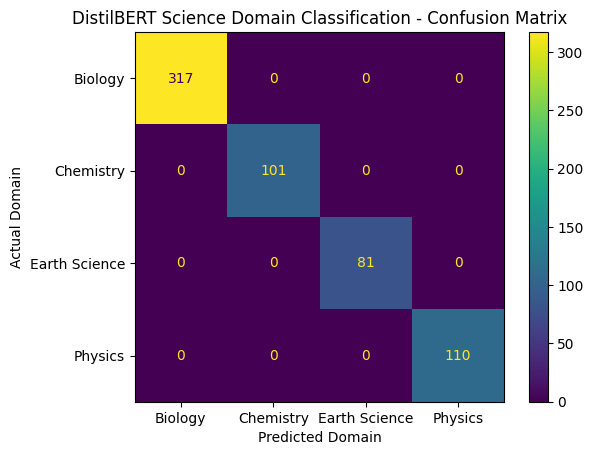

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot()

plt.title("DistilBERT Science Domain Classification - Confusion Matrix")
plt.xlabel("Predicted Domain")
plt.ylabel("Actual Domain")
plt.show()

In [16]:
import torch
import torch.nn.functional as F

new_questions = [
    "What organ pumps blood throughout the human body?",
    "What is the chemical formula for water?",
    "What force keeps planets in orbit around the Sun?",
    "What type of rock is formed when magma cools and solidifies?"
]

inputs = tokenizer(
    new_questions,
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

inputs = {key: value.to(device) for key, value in inputs.items()}

model.eval()

with torch.no_grad():
    outputs = model(**inputs)

probabilities = F.softmax(outputs.logits, dim=1)

predicted_labels = torch.argmax(probabilities, dim=1)

print("PREDICTION CONFIDENCE")
print("=" * 70)

for question, label, probs in zip(
    new_questions,
    predicted_labels,
    probabilities
):
    confidence = probs[label].item() * 100

    print("\nQuestion:", question)
    print("Predicted Domain:", id2label[label.item()])
    print(f"Confidence: {confidence:.2f}%")

PREDICTION CONFIDENCE

Question: What organ pumps blood throughout the human body?
Predicted Domain: Biology
Confidence: 99.82%

Question: What is the chemical formula for water?
Predicted Domain: Physics
Confidence: 72.73%

Question: What force keeps planets in orbit around the Sun?
Predicted Domain: Earth Science
Confidence: 57.96%

Question: What type of rock is formed when magma cools and solidifies?
Predicted Domain: Earth Science
Confidence: 99.48%


In [17]:
# Save the trained model
model.save_pretrained("./science_domain_model")

# Save the tokenizer
tokenizer.save_pretrained("./science_domain_model")

print("Model and tokenizer saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved successfully!


In [18]:
import json

label_mapping = {
    "0": "Biology",
    "1": "Chemistry",
    "2": "Earth Science",
    "3": "Physics"
}

with open("./science_domain_model/label_mapping.json", "w") as f:
    json.dump(label_mapping, f, indent=4)

print("Label mapping saved successfully!")

Label mapping saved successfully!


In [19]:
def predict_domain(question):
    model.eval()

    inputs = tokenizer(
        question,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        outputs = model(**inputs)

    predicted_label = torch.argmax(outputs.logits, dim=1).item()

    return id2label[predicted_label]


# Test the function
question = "What is the process by which plants make their own food?"

result = predict_domain(question)

print("Question:", question)
print("Predicted Domain:", result)

Question: What is the process by which plants make their own food?
Predicted Domain: Biology


In [20]:
question = "What causes an object to accelerate?"

domain = predict_domain(question)

print(domain)

Physics


In [21]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

saved_path = "./science_domain_model"

loaded_tokenizer = AutoTokenizer.from_pretrained(saved_path)

loaded_model = AutoModelForSequenceClassification.from_pretrained(
    saved_path
)

loaded_model.to(device)
loaded_model.eval()

print("Saved model loaded successfully!")
print("Device:", device)
print("Labels:", loaded_model.config.id2label)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Saved model loaded successfully!
Device: cuda
Labels: {0: 'Biology', 1: 'Chemistry', 2: 'Earth Science', 3: 'Physics'}


In [22]:
def classify_science_question(question):
    loaded_model.eval()

    inputs = loaded_tokenizer(
        question,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        outputs = loaded_model(**inputs)

    probabilities = torch.softmax(outputs.logits, dim=1)

    predicted_id = torch.argmax(probabilities, dim=1).item()

    predicted_domain = loaded_model.config.id2label[predicted_id]
    confidence = probabilities[0][predicted_id].item()

    return {
        "question": question,
        "domain": predicted_domain,
        "confidence": confidence
    }


# Test
result = classify_science_question(
    "What is the process by which plants make their own food?"
)

print(result)

{'question': 'What is the process by which plants make their own food?', 'domain': 'Biology', 'confidence': 0.9980577826499939}


In [23]:
def member1_output(question):
    result = classify_science_question(question)

    return {
        "question": result["question"],
        "predicted_domain": result["domain"],
        "confidence": round(result["confidence"], 4)
    }


# Example
output = member1_output(
    "What causes an object to accelerate?"
)

print("MEMBER 1 OUTPUT")
print("=" * 50)
print("Question:", output["question"])
print("Predicted Domain:", output["predicted_domain"])
print("Confidence:", output["confidence"])

MEMBER 1 OUTPUT
Question: What causes an object to accelerate?
Predicted Domain: Physics
Confidence: 0.8551


In [24]:
import os

os.makedirs("Member1_results", exist_ok=True)

print("Results folder created!")

Results folder created!


In [25]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

with open("Member1_results/classification_report.txt", "w") as f:
    f.write(report)

print("Classification report saved!")

Classification report saved!


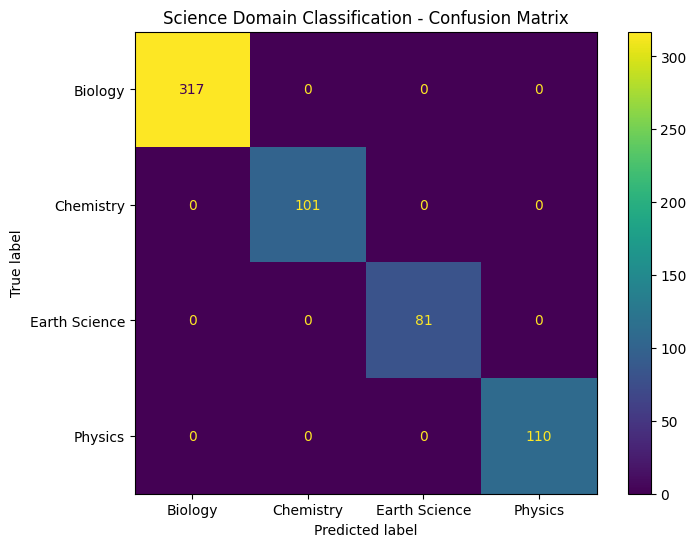

Confusion matrix saved!


In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(ax=ax)

ax.set_title("Science Domain Classification - Confusion Matrix")

plt.savefig(
    "Member1_results/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved!")

In [32]:
readme_text = """# Member 1 - Science Domain Classification

## Objective

Member 1 is responsible for classifying a science question into one of four science domains before it is passed to the next stage of the text-to-video pipeline.

## Science Domains

The model classifies questions into:

1. Biology
2. Chemistry
3. Earth Science
4. Physics

Astronomy was excluded from the project scope.

## Dataset

The project uses the ScienceQA dataset.

After filtering and preprocessing, the final dataset contains:

- Training: 2,519 questions
- Validation: 723 questions
- Test: 609 questions
- Total: 3,851 questions

## Data Preprocessing

The following preprocessing steps were performed:

- Selected science-related questions
- Selected the four required domains
- Removed unwanted categories
- Removed duplicate/conflicting examples
- Checked for overlap between train, validation and test sets
- Converted domain names into numerical labels
- Tokenized questions using the DistilBERT tokenizer

## Model

The classification model used is:

`distilbert-base-uncased`

The pretrained DistilBERT model was fine-tuned for four-class science domain classification.

## Label Mapping

| Label | Domain |
|------:|--------|
| 0 | Biology |
| 1 | Chemistry |
| 2 | Earth Science |
| 3 | Physics |

## Training

Training was performed using a Tesla T4 GPU.

The model was trained for 4 epochs with:

- Batch size: 16
- Learning rate: 2e-5
- Weight decay: 0.01
- FP16 enabled

## Evaluation

On the prepared test set of 609 questions, the model achieved:

- Accuracy: 100%
- Precision: 100%
- Recall: 100%
- F1-score: 100%

## Output

The Member 1 module accepts a science question and returns:

- Original question
- Predicted science domain
- Prediction confidence

Example:

Input:
"What causes an object to accelerate?"

Output:
"Physics"

## Role in the Text-to-Video Pipeline

User Question
       ↓
Member 1: Science Domain Classification
       ↓
Biology / Chemistry / Earth Science / Physics
       ↓
Next Module
       ↓
Text-to-Video Generation
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_text)

print("README.md created successfully!")

README.md created successfully!


In [29]:
requirements_text = """torch
transformers
datasets
scikit-learn
numpy
pandas
matplotlib
accelerate
"""

with open("requirements.txt", "w", encoding="utf-8") as f:
    f.write(requirements_text)

print("requirements.txt created successfully!")

requirements.txt created successfully!
